In [1]:
%load_ext autoreload
%autoreload 2

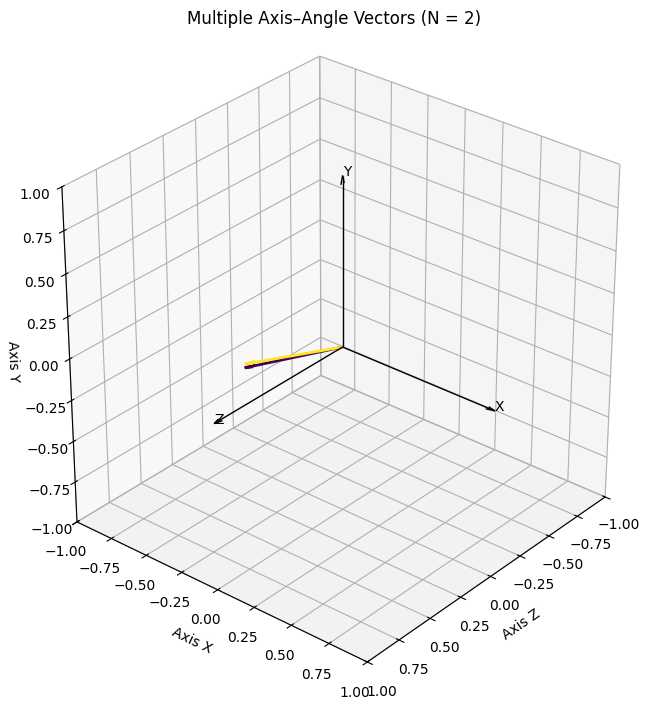

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection


def visualize_axis_angle_vector(axis_angle, title="Axis–Angle Rotation(s)", scale=1.0):
    """Visualize one or more axis–angle rotations in 3D.

    Parameters
    ----------
    axis_angle : array-like of shape (3,) or (N, 3)
        One axis–angle vector or an array of vectors, where direction is the
        rotation axis and its norm is the rotation magnitude (e.g., in radians).
    title : str
        Title for the plot.
    scale : float
        Global scaling factor applied to the drawn vector lengths
        (useful if angles are large).
    """
    axis_angles = np.asarray(axis_angle, dtype=float)

    # Allow a single vector or a batch of vectors
    if axis_angles.ndim == 1:
        axis_angles = axis_angles.reshape(1, 3)
    elif axis_angles.ndim != 2 or axis_angles.shape[1] != 3:
        raise ValueError("axis_angle must have shape (3,) or (N, 3)")

    # Rotation magnitudes and normalized axes
    angles = np.linalg.norm(axis_angles, axis=1)
    axes = np.empty_like(axis_angles)
    for i, (vec, angle) in enumerate(zip(axis_angles, angles)):
        if angle < 1e-8:
            # Degenerate case: no rotation, pick arbitrary axis
            axes[i] = np.array([1.0, 0.0, 0.0], dtype=float)
        else:
            axes[i] = vec / angle

    lengths = angles * scale

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")

    # Draw a coordinate frame
    max_length = np.max(np.abs(lengths)) if len(lengths) > 0 else 1.0
    axis_lim = max(max_length, 1.0)
    ax.quiver(0, 0, 0, axis_lim, 0, 0, color="k", linewidth=1, arrow_length_ratio=0.05)
    ax.quiver(0, 0, 0, 0, axis_lim, 0, color="k", linewidth=1, arrow_length_ratio=0.05)
    ax.quiver(0, 0, 0, 0, 0, axis_lim, color="k", linewidth=1, arrow_length_ratio=0.05)
    ax.text(axis_lim, 0, 0, "X", color="k")
    ax.text(0, axis_lim, 0, "Y", color="k")
    ax.text(0, 0, axis_lim, "Z", color="k")

    # Colormap for multiple vectors
    cmap = plt.cm.viridis
    n = len(axis_angles)

    # Draw each rotation axis scaled by its angle
    for i, (axis_vec, length, angle) in enumerate(zip(axes, lengths, angles)):
        vx, vy, vz = axis_vec * length
        if n == 1:
            color = "tab:blue" if angle >= 0 else "tab:red"
        else:
            color = cmap(i / max(n - 1, 1))

        ax.quiver(
            0, 0, 0,
            vx, vy, vz,
            color=color,
            arrow_length_ratio=0.1,
            linewidth=2,
        )

        # Mark the endpoint
        # ax.scatter([vx], [vy], [vz], color=color, s=60)

    ax.set_title(title + f" (N = {n})")
    ax.set_xlabel("Axis X")
    ax.set_ylabel("Axis Y")
    ax.set_zlabel("Axis Z")

    # Set symmetric limits based on all vectors
    if n > 0:
        all_points = (axes * lengths[:, None]).reshape(-1, 3)
        max_range = max(axis_lim, np.max(np.abs(all_points)))
    else:
        max_range = axis_lim

    for setter in (ax.set_xlim, ax.set_ylim, ax.set_zlim):
        setter(-max_range, max_range)
    ax.set_box_aspect([1, 1, 1])
    ax.view_init(elev=30, azim=40, vertical_axis="y")

    plt.tight_layout()
    plt.show()


# Example usage:
if __name__ == "__main__":
    num_angles = 2

    axis = np.random.randn(1, 3).repeat(num_angles, axis=0)

    axis[1, 0] += np.random.randn() * 0.1
    axis /= np.linalg.norm(axis, axis=1, keepdims=True)

    angles = np.random.uniform(0, 2 * np.pi, size=1)[None].repeat(num_angles, axis=0)

    axis_angles_multi = axis * angles


    # Visualize multiple vectors on the same plot
    visualize_axis_angle_vector(axis_angles_multi, title="Multiple Axis–Angle Vectors", scale=0.5)